# Event-Related Potential (ERP) Analysis Tutorial

## Part of the open_dvm Toolbox

This tutorial demonstrates how to compute, visualize, and analyze event-related potentials (ERPs) using the open_dvm toolbox with real data from a visual search experiment.

## Learning Objectives

After completing this tutorial, you will:

- **Understand the open_dvm ERP workflow** — Initialize an ERP object and call analysis methods
- **Compute group-level ERPs** — Average activity across experimental conditions and subjects
- **Create lateralized difference waveforms** — Generate contra-ipsilateral comparisons
- **Visualize waveforms with publication-quality figures** — Group-level plots with error bands
- **Extract ERP metrics for statistics** — Mean amplitude in time windows of interest
- **Document analysis parameters** — Explicitly specify preprocessing and analysis settings for reproducibility
- **Apply best practices** — Baseline correction, filtering, and parameter documentation

**Prerequisites:** This tutorial requires preprocessed EEG data. You have two options:
1. **Use provided preprocessed data** — Download the preprocessed dataset from OSF (recommended for quickly learning the workflow)
2. **Preprocess your own data** — Run the preprocessing pipeline first (see `01_preprocessing.ipynb`)

## Overview: Visual Attention and ERPs

### The Experimental Task

Participants performed a visual search task with the following features:

- **Search display**: 8 shapes (diamonds or circles) arranged in a circle
- **Task**: Report whether a target (unique shape) is present or absent
- **Key manipulation**: Distractors (colored images) appear with spatial bias
- **Conditions**: 2×2 factorial design (target present/absent × distractor present/absent)

### What ERPs Tell Us

ERPs reflect the brain's processing of visual search. In this tutorial, we focus on:

- **Target-lateralized ERPs** — Hemispheric differences (contra - ipsi) in activity based on target location
- **Distractor sensitivity** — How the N2pc component varies with distractor presence/absence
- **Lateralization** — Contralateral minus ipsilateral comparison reveals hemispheric asymmetries

This analysis isolates attention-related activity by comparing brain regions opposite vs. same-side relative to target location.

## Section 1: Setup and Data Loading

### 1.1 Import Required Libraries

In [ ]:
# Add the following line to enable inline plotting in Jupyter
%matplotlib inline
import matplotlib.pyplot as plt

# Add open_dvm package to path (temporary until we create and install the package)
import sys
import os
sys.path.insert(0, '/Users/dvm/Documents/DvM')

# Import open_dvm modules
import warnings
warnings.filterwarnings('ignore')

from open_dvm.analysis import ERP
from open_dvm.support.FolderStructure import FolderStructure
from open_dvm.visualization.plot import plot_erp_timecourse

print("open_dvm imported successfully!")

open_dvm imported successfully!


### 1.2 Set Project Structure and Parameters

Define the project folder and adjust eye-tracking exclusion criteria. The `FolderStructure` class automatically applies these criteria when loading data.

**Eye-Tracking Exclusion:** Trials with eye movements exceeding the visual angle threshold (default: 1°) during the specified window of interest (default: 0-300 ms after stimulus) will be excluded from analysis. This ensures we analyze only fixation-locked trials.

In [3]:
# ============================================
# CHANGE THIS PATH TO YOUR DATA LOCATION
# ============================================
project_folder = '/Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM'
os.chdir(project_folder)

# Subject number (1-7 in this dataset)
sj = 1

# Eye-tracking exclusion: remove trials with fixation breaks
# (eye movements > angle_thresh during window_oi)
eye_dict = {
    'use_tracker': True,  # Enable eye-tracking exclusion
    'window_oi': (0, 0.3),  # Window: 0-300 ms post-stimulus
    'angle_thresh': 1,  # Threshold: 1 degree visual angle
    'viewing_dist': 70,  # Viewing distance (cm)
    'screen_res': (1920, 1080),  # Screen resolution (pixels)
    'screen_h': 29,  # Screen height (cm)
    'drift_correct': (-0.2, 0)  # Drift: -200 to 0 ms
}

# Load preprocessed epochs and behavioral data
# (applies eye-tracking exclusion and artifact correction)
df, epochs = FolderStructure().load_processed_epochs(
    sj, 'ses_01_main', 'main', eye_dict
)

# Display what was loaded
print(f'✓ Subject {sj} loaded successfully!')
print(f'  • Epochs: {len(epochs)} trials')
print(f'  • Behavioral data: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'  • Sampling rate: {epochs.info["sfreq"]} Hz')
print(f'  • Channels: {len(epochs.ch_names)} ({epochs.info["ch_names"][:3]}...)')
print(f'  • Time range: {epochs.tmin:.3f} to {epochs.tmax:.3f} s')
print(f'\nCondition counts:')
print(df[['target_cnd', 'dist_cnd']].value_counts().head())

Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/eeg/processed/sub_01_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 20 columns
2891 matching events found
No baseline correction applied
0 projection items activated
Eye channel is not specified in eyedict, using HEOG as default
42 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 1)
✓ Subject 1 loaded successfully!
  • Epochs: 2861 trials
  • Behavioral data: 2861 rows × 21 columns
  • Sampling rate: 512.0 Hz
  • Channels: 39 (['Fp1', 'AF3', 'F7']...)
  • Time range: -0.699 to 1.000 s

Condition counts:
target_cnd  dist_cnd
train       absent      958
absent      absent      478
            present     476
low_prob    absent      359
            present     356
Name: count, dtype: int64


## Section 2: Initialize the ERP Object

The open_dvm ERP class follows a two-step workflow:
1. **Initialize** the object with data and parameters
2. **Execute** the analysis using class methods

### 2.1 ERP Initialization with Parameters

Key parameters:
- `baseline`: Time window for baseline correction (-0.1, 0) = 100 ms before event
- `h_filter`: High-pass filter (30 Hz removes slow noise)
- `l_filter`: Low-pass filter (None = no additional filtering)
- `laplacian`: Laplacian reference (False for standard average reference)
- `downsample`: Spatial downsampling (None = no downsampling)
- `report`: Generate HTML quality report (True)

In [4]:
# Initialize ERP object
# All parameters can be modified after initialization
erp_o = ERP(
    sj=sj,
    epochs=epochs,
    df=df,
    baseline=(-0.1, 0),  # 100 ms before event to event onset
    l_filter=None,  # No low-pass filtering
    h_filter=30,  # High-pass filter at 30 Hz
    laplacian=False,  # No Laplacian reference
    downsample=None,  # No downsampling
    report=True  # Generate quality report
)

print('ERP object initialized successfully!')
print(f'Number of epochs: {len(erp_o.epochs)}')
print(f'Analysis parameters set:')
print(f'  - Baseline window: {erp_o.baseline}')
print(f'  - High-pass filter: {erp_o.h_filter} Hz')

ERP object initialized successfully!
Number of epochs: 2861
Analysis parameters set:
  - Baseline window: (-0.1, 0)
  - High-pass filter: 30 Hz


## Section 3: Target-Lateralized ERP Analysis

Target-lateralized ERPs show hemispheric differences based on **target location**. We create lateralized difference waveforms (contra - ipsi) to isolate attention-related activity sensitive to distractors.

### 3.1 Compute Target-Lateralized Difference Waves

Parameters explanation:
- `cnds`: Conditions to compare (distractor component: absent vs present)
- `pos_labels`: Define left/right for lateralization (target at locations 2, 6)
- `midline`: Restrict to midline distractor positions (0, 4, 8) — this isolates target-driven hemispheric differences by removing confounds from distractor location
- `topo_flip`: Flip hemisphere for location 2 (right targets) so contra/ipsilateral regions align spatially across all target positions in the topography plot
- `time_oi`: Time window of interest for analysis (-0.1 to 0.4 s)
- `excl_factor`: Exclude training trials (block_type='loc')
- `name`: Identifier for results file name

In [ ]:
# Compute target-lateralized difference waves
# Compare: distractor absent vs present, lateralized by target location
# Note: midline restriction (dist_loc=[0,4,8]) removes distractor location
# confounds, isolating pure target-driven hemispheric differences
erp_o.condition_erps(
    cnds=dict(dist_cnd=['absent', 'present']),
    pos_labels=dict(target_loc=[2, 6]),  # Lateralize by target (R/L)
    midline=dict(dist_loc=[0, 4, 8]),  # Keep distractors on vertical axis
    topo_flip=dict(target_loc=[2]),  # Flip right targets for aligned topography
    time_oi=(-0.1, 0.4),  # 100 ms pre to 400 ms post
    excl_factor=dict(block_type=['loc']),  # Exclude training trials
    name='target_lateralized'
)

print('Target-lateralized ERP analysis completed!')
print('\nAnalysis saved to: erp/target_lateralized/')

Dropped 958 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Setting up low-pass filter at 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 227 samples (0.443 s)

No flip dictionary specified. Creating flip based on epochs layout. Assumes that odd electrodes are left and even electrodes are right
flipping topography
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Embedding : jquery-3.6.0.min.js
Embedding : bootstrap.bundle.min.js
Embedding : bootstrap.min.css
Embedding : bootstrap-table/bootstrap-table.min.js
Embedding : bootstrap-table/bootstrap-table.min.css
Embedding : boo

### 3.2 Visualize Group-Level Target-Lateralized Waveforms

Compute the target-lateralized analysis for all subjects, then aggregate and visualize group-level results.

In [ ]:
# Run target-lateralized analysis for remaining subjects (2-7)
print('Computing target-lateralized ERPs for subjects 2-7...')
for subject_id in range(2, 8):
    # Load data for this subject
    df_sj, epochs_sj = FolderStructure().load_processed_epochs(
        subject_id, 'ses_01_main', 'main', eye_dict
    )
    
    # Initialize and analyze
    erp_sj = ERP(sj=subject_id, epochs=epochs_sj, df=df_sj,
                 baseline=(-0.1, 0), h_filter=30, l_filter=None,
                 laplacian=False, downsample=None, report=False)
    
    # Compute target-lateralized ERPs
    erp_sj.condition_erps(
        cnds=dict(dist_cnd=['absent', 'present']),
        pos_labels=dict(target_loc=[2, 6]),
        midline=dict(dist_loc=[0, 4, 8]),
        topo_flip=dict(target_loc=[2]),
        time_oi=(-0.1, 0.4),
        excl_factor=dict(block_type=['loc']),
        name='target_lateralized'
    )
    print(f'  ✓ Subject {subject_id} complete')

print('\n✓ All subjects processed.')

Computing target-lateralized ERPs for subjects 2-7...
Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/eeg/processed/sub_02_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 20 columns
2902 matching events found
No baseline correction applied
0 projection items activated
4 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 1)
Dropped 498 trials after specifying excl_factor
NOTE DROPPING IS DONE IN PLACE. PLEASE REREAD DATA IF THAT CONDITION IS NECESSARY AGAIN
Setting up low-pass filter at 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 30.00 Hz
- Upper transition bandwid

### 3.3 Load and Visualize Group-Level Results

Use open_dvm's `read_erps()` function to load aggregated results across all subjects for group-level visualization and analysis.

#### 3.3a Load Group Data

Load the aggregated group-level ERP data across all subjects using the FolderStructure API.

In [8]:
# Load group-level ERP data across all subjects
print('Loading group-level target-lateralized ERPs...')
erp_data, times = FolderStructure().read_erps(
    erp_name='target_lateralized',
    cnds=['absent', 'present'],
    sjs='all'
)

print(f'✓ Group data loaded successfully')
print(f'  • Conditions: {list(erp_data.keys())}')
print(f'  • Time points: {len(times)}')
print(f'  • Waveforms per condition: {[len(v) for v in erp_data.values()]}')
print(f'\nGroup-level waveforms ready for visualization and statistics')

Loading group-level target-lateralized ERPs...
✓ Group data loaded successfully
  • Conditions: ['absent', 'present']
  • Time points: 257
  • Waveforms per condition: [7, 7]

Group-level waveforms ready for visualization and statistics


#### 3.3b Visualize Group Waveforms

Plot the group-level ERPs to visualize hemispheric differences (contralateral - ipsilateral) across distractor conditions.

Plotting group-level target-lateralized waveforms...
Data for condition 'absent' converted from volts to microvolts
bootstrapping using 9999 iterations
Data for condition 'present' converted from volts to microvolts
bootstrapping using 9999 iterations


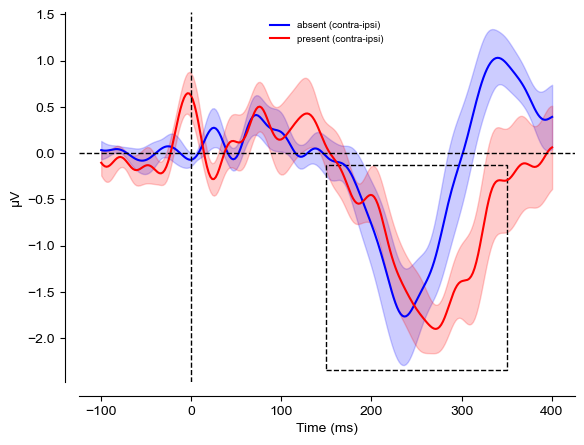


Waveform shows contra-ipsi hemispheric differences.


In [21]:
# Visualize group-level waveforms
print('Plotting group-level target-lateralized waveforms...')
plot_erp_timecourse(
    erp_data,
    times=times*1000,  # Convert to milliseconds
    elec_oi=[['PO3'], ['PO4']],  # Posterior lateral electrodes
    lateralized=True,
    cnds=['absent', 'present'],
    colors=['blue', 'red'],
    show_SE=True,
    window_oi=(150, 350, 'neg'),  # Highlight N2pc window (150-350 ms)
    show_legend=True
)
plt.show()

print('\nWaveform shows contra-ipsi hemispheric differences.')

#### 3.3c Extract ERP Metrics for Statistical Analysis

Now extract mean amplitudes in the N2pc time window (150-350 ms) at posterior electrodes. These metrics will be used for statistical comparisons between conditions.

In [23]:
# Extract ERP metrics for statistics
print('Extracting ERP metrics in time windows of interest...')

# Select time window for analysis
window_oi = ERP.select_erp_window(
    erp_data,
    elec_oi=[['PO3'], ['PO4']],
    method='cnd_avg',
    window_oi=(0.15, 0.35),  # 150-350 ms (typical N2pc window)
    polarity='neg'
)

print(f'Selected window: {window_oi}')

# Export metrics to CSV for statistical analysis
ERP.export_erp_metrics_to_csv(
    erp_data,
    window_oi=window_oi,
    elec_oi=[['PO3'], ['PO4']],
    cnds=['absent', 'present'],
    method='mean_amp',
    name='target_lateralized_metrics'
)

print('\n✓ Metrics exported to CSV for statistical analysis')
print('  File: target_lateralized_metrics.csv')

Extracting ERP metrics in time windows of interest...
Selected window: [np.float64(0.219140625), np.float64(0.269140625), 'neg']

✓ Metrics exported to CSV for statistical analysis
  File: target_lateralized_metrics.csv


## Section 5: Best Practices and Reproducibility

### 5.1 Common Pitfalls and Best Practices

**Best Practices:**
- ✓ Always document baseline correction window
- ✓ Specify filter settings clearly
- ✓ Report number of trials per condition
- ✓ Save analysis parameters in a dictionary for reproducibility

**Common Pitfalls:**
- ✗ Changing filters after baseline correction
- ✗ Using different baseline windows for different conditions
- ✗ Not documenting preprocessing steps
- ✗ Analyzing too many time windows without correction

In [26]:
# Save analysis parameters for documentation
analysis_params = {
    'subject': sj,
    'data_version': 'ses_01_main',
    'preprocessing_name': 'main',
    'montage': 'biosemi32',
    'baseline_window': (-0.1, 0),
    'epoch_window': (-0.2, 0.5),
    'high_pass_filter': 30,
    'low_pass_filter': None,
    'laplacian': False,
    'analysis_time_window': (-0.1, 0.4),
    'eye_tracking_used': True,
}

print('Analysis parameters saved:')
for key, value in analysis_params.items():
    print(f'  {key}: {value}')

Analysis parameters saved:
  subject: 1
  data_version: ses_01_main
  preprocessing_name: main
  montage: biosemi32
  baseline_window: (-0.1, 0)
  epoch_window: (-0.2, 0.5)
  high_pass_filter: 30
  low_pass_filter: None
  laplacian: False
  analysis_time_window: (-0.1, 0.4)
  eye_tracking_used: True


## Section 6: References and Further Reading

### Papers on ERPs in Visual Attention Research

**Foundational Work:**
- Luck, S. J., & Hillyard, S. A. (1994). Spatial filtering during visual search: Evidence from human electrophysiology. *Journal of Experimental Psychology: Human Perception and Performance*, 20(4), 1000-1014.

**N2pc Component:**
- Woodman, G. F., & Luck, S. J. (1999). Electrophysiological evidence for a postperceptual locus of suppression during the attentional blink. *Journal of Cognitive Neuroscience*, 11(6), 1-11.

### MNE-Python Documentation
- MNE-Python Tutorials: https://mne.tools/stable/auto_tutorials/index.html
- ERP visualization: https://mne.tools/stable/auto_examples/time_frequency/plot_erp.html
- Baseline correction: https://mne.tools/stable/generated/mne.Epochs.html#mne.Epochs.apply_baseline

### open_dvm Documentation
- See NAMING_CONVENTIONS.md for file organization standards
- See README.md for installation and setup instructions

## Summary

In this tutorial, you learned how to:

1. **Load preprocessed EEG data** using the open_dvm FolderStructure system
2. **Initialize an ERP object** with preprocessing and analysis parameters
3. **Compute group-level target-lateralized ERPs** using the condition_erps() method
4. **Create lateralized difference waveforms** to isolate attention-related activity
5. **Visualize group results** with publication-quality waveforms and error bands
6. **Extract ERP metrics** from time windows of interest for statistical analysis
7. **Follow reproducibility best practices** for publication-quality analysis

The workflow demonstrated here (initialize → compute → load → visualize → extract metrics) is consistent across all open_dvm analyses, making it intuitive to apply these skills to TFR, BDM, and CTF analyses in subsequent tutorials.

**For advanced analyses** (e.g., distractor-lateralized processing, jackknife contrasts), see the dedicated advanced ERP tutorial.